# 01 Extract Siamese Training Pairs

This notebook extracts image pairs for training the Siamese network.

Pair labels:
- `0` = same payload state / normal operation
- `1` = payload loss / different payload state

For payload loss videos:
- negative pairs are sampled from before-before or after-after regions
- positive pairs are sampled from before-after regions

For normal videos:
- only negative pairs are sampled

The first 30 frames of each video are ignored due to camera startup artifacts. Frames near the loss event are also excluded due to annotation uncertainty.

## 1. Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
from pathlib import Path
import csv
import random
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [11]:
from siamese_utils import (
    set_seed,
    ensure_dirs,
    read_ground_truth,
    get_video_path,
    iter_sampled_video_frames,
    split_loss_frames,
    make_random_pairs,
    save_pair_images,
    clear_extracted_pairs,
    TRAIN_LABELS_CSV,
    EXTRACTED_PAIRS_DIR,
    BUFFER_FRAMES,
    FRAME_STEP,
    IGNORE_FIRST_N_FRAMES,
)

Set the random seed and clear any previously extracted training pairs.

In [12]:
set_seed()
ensure_dirs()
clear_extracted_pairs()

print("Output directory:", EXTRACTED_PAIRS_DIR)
print("Train labels CSV:", TRAIN_LABELS_CSV)
print("Ignore first frames:", IGNORE_FIRST_N_FRAMES)
print("Buffer frames:", BUFFER_FRAMES)
print("Frame step:", FRAME_STEP)

Output directory: /Users/tohjiale/Desktop/payload_loss_detection/siamese/data/extracted_pairs
Train labels CSV: /Users/tohjiale/Desktop/payload_loss_detection/siamese/data/extracted_pairs/train_labels.csv
Ignore first frames: 30
Buffer frames: 35
Frame step: 5


## 2. Load Ground Truth

Load the Siamese training ground truth file from `siamese/data/ground_truth.csv`.

In [13]:
gt = read_ground_truth()
gt.head()

gt["is_loss_event"].value_counts()

is_loss_event
1    104
0     32
Name: count, dtype: int64

## 3. Pair Extraction Settings

The number of pairs is capped per video to avoid generating too many near-duplicate pairs.

The dataset is kept roughly balanced by sampling a similar number of positive and negative pairs from payload loss videos, while limiting negative pairs from normal-operation videos.

In [14]:
# Per-video sampling limits
POSITIVE_PAIRS_PER_LOSS_VIDEO = 80
NEGATIVE_PAIRS_PER_LOSS_VIDEO = 80
NEGATIVE_PAIRS_PER_NORMAL_VIDEO = 40

records = []
pair_id = 0

missing_videos = []
skipped_videos = []

## 4. Extract Image Pairs

Generate and save image pairs into `extracted_pairs/`, then record their paths and labels in `train_labels.csv`.

In [15]:
for _, row in gt.iterrows():
    filename = row["filename"]
    is_loss = int(row["is_loss_event"])
    loss_frame = int(row["loss_frame"])

    video_path = get_video_path(filename)

    if not video_path.exists():
        missing_videos.append(filename)
        continue

    frames = list(iter_sampled_video_frames(video_path))

    if len(frames) < 2:
        skipped_videos.append((filename, "not enough sampled frames"))
        continue

    video_pairs = []

    if is_loss:
        before, after = split_loss_frames(frames, loss_frame)

        if len(before) < 2 or len(after) < 2:
            skipped_videos.append((filename, "not enough before/after frames"))
            continue

        # Negative pairs: same state
        neg_before = make_random_pairs(
            before,
            before,
            label=0,
            num_pairs=NEGATIVE_PAIRS_PER_LOSS_VIDEO // 2,
        )

        neg_after = make_random_pairs(
            after,
            after,
            label=0,
            num_pairs=NEGATIVE_PAIRS_PER_LOSS_VIDEO // 2,
        )

        # Positive pairs: different state
        pos_pairs = make_random_pairs(
            before,
            after,
            label=1,
            num_pairs=POSITIVE_PAIRS_PER_LOSS_VIDEO,
        )

        video_pairs.extend(neg_before)
        video_pairs.extend(neg_after)
        video_pairs.extend(pos_pairs)

    else:
        # Normal-operation videos only produce negative pairs
        video_pairs = make_random_pairs(
            frames,
            frames,
            label=0,
            num_pairs=NEGATIVE_PAIRS_PER_NORMAL_VIDEO,
        )

    for idx1, frame1, idx2, frame2, label in video_pairs:
        img1_rel, img2_rel = save_pair_images(frame1, frame2, pair_id)

        records.append({
            "img1": img1_rel,
            "img2": img2_rel,
            "label": label,
            "source_video": filename,
            "frame1": idx1,
            "frame2": idx2,
        })

        pair_id += 1

print("Total pairs extracted:", len(records))
print("Missing videos:", len(missing_videos))
print("Skipped videos:", len(skipped_videos))

Total pairs extracted: 16640
Missing videos: 0
Skipped videos: 8


## 5. Save Labels

Save the extracted pair metadata in `train_labels.csv` for training.

In [17]:
df = pd.DataFrame(records)

df.to_csv(TRAIN_LABELS_CSV, index=False)

print(f"Saved train labels to: {TRAIN_LABELS_CSV}")
df.head()

Saved train labels to: /Users/tohjiale/Desktop/payload_loss_detection/siamese/data/extracted_pairs/train_labels.csv


,img1,img2,label,source_video,frame1,frame2
0,data/extracted_pairs/pair_000000_1.jpg,data/extracted_pairs/pair_000000_2.jpg,0,videos_normal/back_box_1.mp4,605,160
1,data/extracted_pairs/pair_000001_1.jpg,data/extracted_pairs/pair_000001_2.jpg,0,videos_normal/back_box_1.mp4,1440,1285
2,data/extracted_pairs/pair_000002_1.jpg,data/extracted_pairs/pair_000002_2.jpg,0,videos_normal/back_box_1.mp4,1175,745
3,data/extracted_pairs/pair_000003_1.jpg,data/extracted_pairs/pair_000003_2.jpg,0,videos_normal/back_box_1.mp4,555,2825
4,data/extracted_pairs/pair_000004_1.jpg,data/extracted_pairs/pair_000004_2.jpg,0,videos_normal/back_box_1.mp4,480,3055


## 6. Dataset Summary

Check the number of positive and negative pairs.

In [18]:
print("Total pairs:", len(df))
print("Negative pairs:", (df["label"] == 0).sum())
print("Positive pairs:", (df["label"] == 1).sum())

df["label"].value_counts(normalize=True)

Total pairs: 16640
Negative pairs: 8960
Positive pairs: 7680


label
0    0.538462
1    0.461538
Name: proportion, dtype: float64

In [19]:
df.groupby("label")["source_video"].nunique()

label
0    128
1     96
Name: source_video, dtype: int64

## 7. Check Missing or Skipped Videos

Review any videos that were not used.

In [20]:
missing_videos[:10], skipped_videos[:10]

([],
 [('videos_loss/back_001.mp4', 'not enough before/after frames'),
  ('videos_loss/back_002.mp4', 'not enough before/after frames'),
  ('videos_loss/front_001.mp4', 'not enough before/after frames'),
  ('videos_loss/front_002.mp4', 'not enough before/after frames'),
  ('videos_loss/left_001.mp4', 'not enough before/after frames'),
  ('videos_loss/left_002.mp4', 'not enough before/after frames'),
  ('videos_loss/right_001.mp4', 'not enough before/after frames'),
  ('videos_loss/right_002.mp4', 'not enough before/after frames')])

## 8. Verify Image Properties

Confirm that extracted images can be loaded correctly.

In [23]:
sample_row = df.iloc[0]

img1_path = Path(sample_row["img1"])
img2_path = Path(sample_row["img2"])

img1 = cv2.imread(str(img1_path))
img2 = cv2.imread(str(img2_path))

print("Image 1 shape:", img1.shape, "dtype:", img1.dtype)
print("Image 2 shape:", img2.shape, "dtype:", img2.dtype)

Image 1 shape: (120, 160, 3) dtype: uint8
Image 2 shape: (120, 160, 3) dtype: uint8


## 9. Visualize Sample Pairs

Display sample negative and positive pairs to verify that labels are correct.

In [24]:
def show_pair(row):
    img1_path = Path(row["img1"])
    img2_path = Path(row["img2"])

    img1 = cv2.cvtColor(cv2.imread(str(img1_path)), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(cv2.imread(str(img2_path)), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(f"Frame {row['frame1']}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(f"Frame {row['frame2']} | Label {row['label']}")
    plt.axis("off")

    plt.suptitle(row["source_video"])
    plt.show()

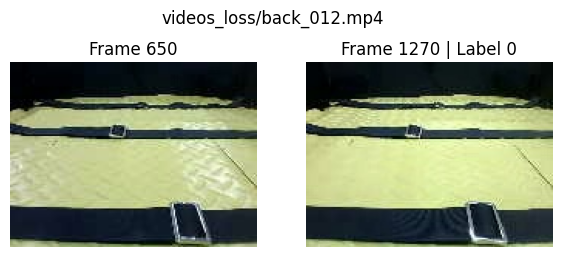

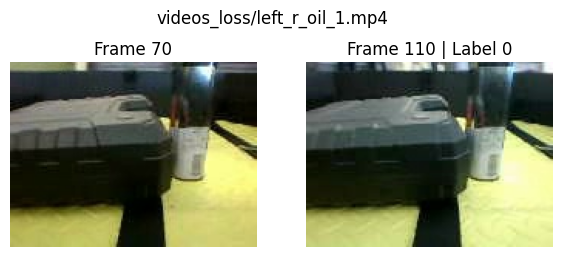

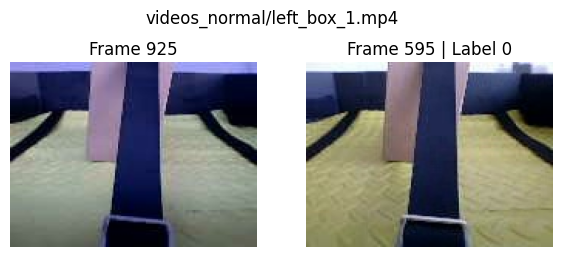

In [25]:
# Negative samples
negative_samples = df[df["label"] == 0].sample(min(3, (df["label"] == 0).sum()), random_state=42)

for _, row in negative_samples.iterrows():
    show_pair(row)

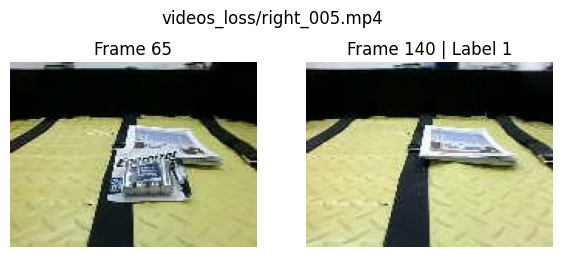

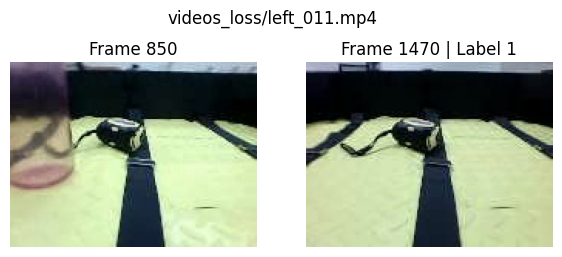

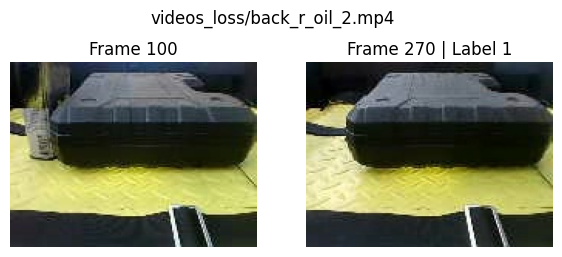

In [26]:
# Positive samples
positive_samples = df[df["label"] == 1].sample(min(3, (df["label"] == 1).sum()), random_state=42)

for _, row in positive_samples.iterrows():
    show_pair(row)

## 10. Final Check

The extracted dataset is ready:
- both classes have a reasonable number of pairs ✅ 8960+7680
- sample negative pairs look similar ✅ 
- sample positive pairs show a clear payload change ✅ 
- no major videos are missing or skipped unexpectedly ✅ 

In [27]:
df.tail()

,img1,img2,label,source_video,frame1,frame2
16635,data/extracted_pairs/pair_016635_1.jpg,data/extracted_pairs/pair_016635_2.jpg,1,videos_loss/right_r_tools_1.mp4,75,495
16636,data/extracted_pairs/pair_016636_1.jpg,data/extracted_pairs/pair_016636_2.jpg,1,videos_loss/right_r_tools_1.mp4,40,425
16637,data/extracted_pairs/pair_016637_1.jpg,data/extracted_pairs/pair_016637_2.jpg,1,videos_loss/right_r_tools_1.mp4,100,510
16638,data/extracted_pairs/pair_016638_1.jpg,data/extracted_pairs/pair_016638_2.jpg,1,videos_loss/right_r_tools_1.mp4,160,380
16639,data/extracted_pairs/pair_016639_1.jpg,data/extracted_pairs/pair_016639_2.jpg,1,videos_loss/right_r_tools_1.mp4,160,355
